<a href="https://colab.research.google.com/github/liuxiaohu0511/lance-demo/blob/develop/lance-quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install pylance

In [8]:
import shutil
import lance
import numpy as np
import pandas as pd
import pyarrow as pa

In [10]:
df = pd.DataFrame({"a": [5,1,2],"b":['1','2','3']})
df

,a,b
0,5,1
1,1,2
2,2,3


In [11]:
shutil.rmtree("/tmp/test.lance", ignore_errors=True)

dataset = lance.write_dataset(df, "/tmp/test.lance")
dataset.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [12]:
shutil.rmtree("/tmp/test.parquet", ignore_errors=True)
shutil.rmtree("/tmp/test.lance", ignore_errors=True)

tbl = pa.Table.from_pandas(df)
pa.dataset.write_dataset(tbl, "/tmp/test.parquet", format='parquet')

parquet = pa.dataset.dataset("/tmp/test.parquet")
parquet.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [13]:
dataset = lance.write_dataset(parquet, "/tmp/test.lance")

# Make sure it's the same
dataset.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [14]:
# lance 版本控制

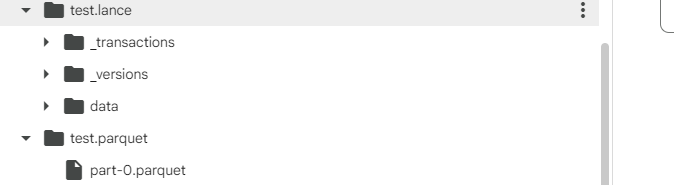

In [15]:
# lance 版本控制
# 将新数据附加到数据集
df = pd.DataFrame({"a": [10]})
tbl = pa.Table.from_pandas(df)
dataset = lance.write_dataset(tbl, "/tmp/test.lance", mode="append")
dataset.to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3
3,10,None


In [17]:
# 覆盖你的数据集
df = pd.DataFrame({"a": [50, 100]})
tbl = pa.Table.from_pandas(df)
dataset = lance.write_dataset(tbl, "/tmp/test.lance", mode="overwrite")
dataset.to_table().to_pandas()

,a
0,50
1,100


In [ ]:
# 访问先前的数据集版本

In [18]:
dataset.versions()

[{'version': 1,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 18, 37, 334337),
  'metadata': {'total_data_file_rows': '3',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '1127',
   'total_fragments': '1',
   'total_rows': '3'}},
 {'version': 2,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 21, 2, 315300),
  'metadata': {'total_data_file_rows': '4',
   'total_data_files': '2',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '1947',
   'total_fragments': '2',
   'total_rows': '4'}},
 {'version': 3,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 21, 52, 318144),
  'metadata': {'total_data_file_rows': '2',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '718',
   'total_fragments': '1',
   'total_rows': '2'}},
 {'version': 4,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 22, 15, 256326),


In [19]:
# 通过版本访问数据
# version1
lance.dataset('/tmp/test.lance', version=1).to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3


In [20]:
# version2
lance.dataset('/tmp/test.lance', version=2).to_table().to_pandas()


,a,b
0,5,1
1,1,2
2,2,3
3,10,None


为你的版本打上标签

In [24]:
dataset.tags.create("stable", 2)
dataset.tags.create("nightly", 3)
dataset.tags.list()

{'nightly': {'version': 3, 'manifest_size': 660},
 'stable': {'version': 2, 'manifest_size': 880}}

In [25]:
lance.dataset('/tmp/test.lance', version="stable").to_table().to_pandas()

,a,b
0,5,1
1,1,2
2,2,3
3,10,None


3. 矢量搜索

In [26]:
import shutil
import lance
import numpy as np
import pandas as pd
import pyarrow as pa
import duckdb

In [28]:
# 准备向量嵌入
!rm -rf sift* vec_data.lance
!wget ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz
!tar -xzf sift.tar.gz


--2025-10-22 13:31:06--  ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz
           => ‘sift.tar.gz’
Resolving ftp.irisa.fr (ftp.irisa.fr)... 131.254.254.45, 2001:660:7303:254::45
Connecting to ftp.irisa.fr (ftp.irisa.fr)|131.254.254.45|:21... connected.
Logging in as anonymous ... Logged in!
==> SYST ... done.    ==> PWD ... done.
==> TYPE I ... done.  ==> CWD (1) /local/texmex/corpus ... done.
==> SIZE sift.tar.gz ... 168280445
==> PASV ... done.    ==> RETR sift.tar.gz ... done.
Length: 168280445 (160M) (unauthoritative)

sift.tar.gz         100%[===================>] 160.48M  23.5MB/s    in 7.7s    

2025-10-22 13:31:16 (20.9 MB/s) - ‘sift.tar.gz’ saved [168280445]



In [31]:
# 将原始矢量数据转换为 Lance 格式，以便高效存储和查询。
from lance.vector import vec_to_table
import struct

uri = "vec_data.lance"

with open("sift/sift_base.fvecs", mode="rb") as fobj:
    buf = fobj.read()
    data = np.array(struct.unpack("<128000000f", buf[4 : 4 + 4 * 1000000 * 128])).reshape((1000000, 128))
    dd = dict(zip(range(1000000), data))

table = vec_to_table(dd)
lance.write_dataset(table, uri, max_rows_per_group=8192, max_rows_per_file=1024*1024)

In [32]:
# 现在您可以加载数据集
uri = "vec_data.lance"
sift1m = lance.dataset(uri)

In [33]:
sift1m.versions()

[{'version': 1,
  'timestamp': datetime.datetime(2025, 10, 22, 13, 33, 11, 787748),
  'metadata': {'total_data_file_rows': '1000000',
   'total_data_files': '1',
   'total_deletion_file_rows': '0',
   'total_deletion_files': '0',
   'total_files_size': '520001683',
   'total_fragments': '1',
   'total_rows': '1000000'}}]

In [39]:
# 先执行一个没有索引的向搜索，以便后续跟索引搜索做比较
import duckdb
# Make sure DuckDB v0.7+ is installed
samples = duckdb.query("SELECT vector FROM sift1m USING SAMPLE 100").to_df().vector
samples

,vector
0,"[19.0, 19.0, 4.0, 3.0, 24.0, 21.0, 1.0, 0.0, 5..."
1,"[8.0, 111.0, 18.0, 16.0, 56.0, 15.0, 0.0, 0.0,..."
2,"[65.0, 12.0, 2.0, 2.0, 0.0, 2.0, 109.0, 130.0,..."
3,"[4.0, 6.0, 1.0, 1.0, 1.0, 5.0, 1.0, 23.0, 3.0,..."
4,"[68.0, 2.0, 0.0, 5.0, 16.0, 11.0, 54.0, 132.0,..."
...,...
95,"[35.0, 69.0, 76.0, 0.0, 0.0, 47.0, 73.0, 5.0, ..."
96,"[1.0, 25.0, 123.0, 123.0, 19.0, 30.0, 7.0, 3.0..."
97,"[0.0, 21.0, 50.0, 12.0, 30.0, 2.0, 0.0, 0.0, 0..."
98,"[0.0, 0.0, 0.0, 0.0, 12.0, 140.0, 10.0, 1.0, 0..."


In [40]:
samples.shape

(100,)

In [41]:
# 现在，执行不使用索引的最近邻搜索。
# 如果没有索引，搜索将扫描整个数据集来计算每个数据点之间的距离。
# 为了获得实际的实时性能，使用 ANN 索引将获得更好的性能。

import time

start = time.time()
tbl = sift1m.to_table(columns=["id"], nearest={"column": "vector", "q": samples[0], "k": 10})
end = time.time()

print(f"Time(sec): {end-start}")
print(tbl.to_pandas())

Time(sec): 0.618798017501831
       id  _distance
0  578209        0.0
1  515128    57525.0
2  351556    60055.0
3  339430    60824.0
4  284734    63534.0
5  527899    64439.0
6  487264    64806.0
7  611491    64907.0
8  730171    74460.0
9  786673    74629.0
